# 04 - Incremental Demand 

1. Take the last 5 weeks of transactions (4 weeks before, 1 discount week)
2. Count units and average price per article per week
3. An article is "discounted" if its discount-week price is at least `discount_threshold` below its normal price
4. Find the similar non-discounted articles of each discounted article (these are "exposed", we do not use them as controls)
5. For every discounted article, pick 5 similar clean controls (similar text, sales level and sales trend)
6. Difference-in-differences: (discounted after - before) - (controls after - before)

| Table | Contents |
|---|---|
| `hnm_article_treatment_weekly` | one row per article: treated or not, units, price, lift, adjusted lift, categories |
| `hnm_units_long` | article_id, week, units (used by 05) |
| `hnm_exposure_pairs` | discounted article -> its closest non-discounted similar articles (used by 05) |
| `hnm_incremental_demand_did` | one row with the result and the settings 05 must reuse |
| `parallel_trends_demand` | average units per week, discounted vs controls (for the chart) |

In [0]:
%pip install -q statsmodels
%pip install -q seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

In [0]:
# Settings
dbutils.widgets.text("transactions_table", "workspace.default.hnm_transactions_bronze")
dbutils.widgets.text("articles_table", "workspace.default.hnm_articles_bronze")
dbutils.widgets.text("embeddings_schema", "workspace.hnm_discount")        # written by notebook 03
dbutils.widgets.text("output_schema", "workspace.hnm_discount_silver")
dbutils.widgets.text("discount_threshold", "0.05")
dbutils.widgets.text("n_controls_per_treated", "5")
dbutils.widgets.text("exposure_top_n", "3")

transactions_table = dbutils.widgets.get("transactions_table")
articles_table = dbutils.widgets.get("articles_table")
embeddings_schema = dbutils.widgets.get("embeddings_schema")
output_schema = dbutils.widgets.get("output_schema")
discount_threshold = float(dbutils.widgets.get("discount_threshold"))
n_controls_per_treated = int(dbutils.widgets.get("n_controls_per_treated"))
exposure_top_n = int(dbutils.widgets.get("exposure_top_n"))

n_weeks = 5                 # 4 weeks before + 1 discount week
min_baseline_units = 1.0    # ignore articles that sold less than this per week before the discount
lam_level = 0.10            # matching penalty: difference in sales level
lam_slope = 0.30            # matching penalty: difference in sales trend

nn_candidates_table = f"{embeddings_schema}.hnm_article_text_nn_candidates"
embeddings_table = f"{embeddings_schema}.hnm_article_text_embeddings"

article_table = f"{output_schema}.hnm_article_treatment_weekly"
units_long_table = f"{output_schema}.hnm_units_long"
exposure_pairs_table = f"{output_schema}.hnm_exposure_pairs"
did_results_table = f"{output_schema}.hnm_incremental_demand_did"
parallel_trends_table = f"{output_schema}.parallel_trends_demand"

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {output_schema}")

def save_table(pdf, name):
    spark.createDataFrame(pdf).write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(name)
    print("wrote", name)

In [0]:
# Find the last 5 weeks (weeks start on Monday)
trans = spark.table(transactions_table)
trans = trans.withColumn("week_start", F.date_format(F.date_trunc("week", F.col("t_dat")), "yyyy-MM-dd"))

all_weeks = sorted([r["week_start"] for r in trans.select("week_start").distinct().collect()])
weeks = all_weeks[-n_weeks:]
assert len(weeks) == n_weeks, "not enough weeks of data"
week_number = {w: i + 1 for i, w in enumerate(weeks)}      # oldest = 1, newest = 5
treatment_week = n_weeks

recent = trans.filter(F.col("week_start").isin(weeks))

# Weeks 1-4 are the "before" weeks, week 5 is the discount week
retained_pre = list(range(1, treatment_week))
print("treatment week:", treatment_week, "| weeks used as 'before':", retained_pre)

treatment week: 5 | weeks used as 'before': [1, 2, 3, 4]


In [0]:
# Units and total price per article per week
weekly = (recent.groupBy("article_id", "week_start")
          .agg(F.count("*").alias("units"), F.sum("price").alias("sum_price"))
          .toPandas())
weekly["article_id"] = weekly["article_id"].astype(str)
weekly["week"] = weekly["week_start"].map(week_number)

week_list = list(range(1, n_weeks + 1))
units = weekly.pivot(index="article_id", columns="week", values="units").reindex(columns=week_list).fillna(0)
sum_price = weekly.pivot(index="article_id", columns="week", values="sum_price").reindex(columns=week_list).fillna(0)
print("articles sold in the 5 weeks:", len(units))

articles sold in the 5 weeks: 31014


In [0]:
# Who got a discount?
df = pd.DataFrame(index=units.index)
df["baseline_units"] = units[retained_pre].mean(axis=1)
df["week5_units"] = units[treatment_week]

baseline_price = sum_price[retained_pre].sum(axis=1) / units[retained_pre].sum(axis=1).replace(0, np.nan)
week5_price = sum_price[treatment_week] / units[treatment_week].replace(0, np.nan)

df["price"] = week5_price
df["discount_pct"] = 1 - week5_price / baseline_price
df["T"] = (df["discount_pct"] >= discount_threshold).astype(int)
df["lift_units"] = df["week5_units"] - df["baseline_units"]

# Keep only articles that sold normally before AND sold in the discount week
keep = (df["baseline_units"] >= min_baseline_units) & (df["week5_units"] > 0)
print("articles kept:", int(keep.sum()), "of", len(df),
      "| discounted:", int((keep & (df["T"] == 1)).sum()),
      "| not discounted:", int((keep & (df["T"] == 0)).sum()))

df = df[keep].copy()
units = units.loc[df.index]
df = df.reset_index()           # article_id becomes a normal column

# add product names and categories
categories = (spark.table(articles_table)
              .select("article_id", "prod_name", "colour_group_name", "garment_group_name", "department_name",
                      "product_group_name", "index_name", "product_type_name", "section_name")
              .dropDuplicates(["article_id"]).toPandas())
categories["article_id"] = categories["article_id"].astype(str)
df = df.merge(categories, on="article_id", how="left")
category_columns = [c for c in categories.columns if c != "article_id"]
df[category_columns] = df[category_columns].fillna("Unknown")

articles kept: 14519 of 31014 | discounted: 2777 | not discounted: 11742


In [0]:
# Exposed articles = the closest non-discounted similar articles of each discounted article.
# Their sales may be hurt by the discount, so they are NOT used as controls.
treated_ids = df.loc[df["T"] == 1, "article_id"].tolist()
not_discounted = set(df.loc[df["T"] == 0, "article_id"])

neighbors = (spark.table(nn_candidates_table)
             .filter(F.col("anchor_id").isin(treated_ids))
             .select("anchor_id", "candidate_id", "final_score")
             .toPandas())

neighbors = neighbors[neighbors["candidate_id"].isin(not_discounted)]       # drop discounted candidates FIRST
neighbors = neighbors.sort_values(["anchor_id", "final_score", "candidate_id"], ascending=[True, False, True])
neighbors["rk"] = neighbors.groupby("anchor_id").cumcount() + 1
exposure_pairs = neighbors[neighbors["rk"] <= exposure_top_n].reset_index(drop=True)

exposed = set(exposure_pairs["candidate_id"])
print("exposure pairs:", len(exposure_pairs), "| distinct exposed articles:", len(exposed))

exposure pairs: 7946 | distinct exposed articles: 4309


In [0]:
# Features used for matching: sales level and sales trend before the discount
pre = units[retained_pre].to_numpy(dtype=float)
x = np.array(retained_pre, dtype=float)
x = x - x.mean()

feat = pd.DataFrame(index=units.index)
feat["pre_units"] = pre.mean(axis=1)
feat["post_units"] = units[treatment_week].to_numpy(dtype=float)
feat["log_level"] = np.log1p(feat["pre_units"])
feat["slope"] = (np.log1p(pre) * x).sum(axis=1) / (x ** 2).sum()

# text embeddings from notebook 03
emb = (spark.table(embeddings_table)
       .select(F.col("article_id").cast("string").alias("article_id"), F.col("text_embedding").alias("embedding"))
       .toPandas().drop_duplicates("article_id").set_index("article_id"))

treated_ok = sorted(set(treated_ids) & set(emb.index))
control_ids = sorted((not_discounted - exposed) & set(emb.index))
print("discounted articles:", len(treated_ok), "| clean controls available:", len(control_ids))

def unit_vectors(ids):
    X = np.vstack(emb.loc[ids, "embedding"]).astype("float32")
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

Xt = unit_vectors(treated_ok)
Xc = unit_vectors(control_ids)
level_t = feat.loc[treated_ok, "log_level"].to_numpy()[:, None]
level_c = feat.loc[control_ids, "log_level"].to_numpy()[None, :]
slope_t = feat.loc[treated_ok, "slope"].to_numpy()[:, None]
slope_c = feat.loc[control_ids, "slope"].to_numpy()[None, :]

k = min(n_controls_per_treated, len(control_ids))
assert k > 0, "no clean controls available"

rows = []
for start in range(0, len(treated_ok), 500):
    end = start + 500
    similarity = Xt[start:end] @ Xc.T
    score = (similarity
             - lam_level * np.abs(level_t[start:end] - level_c)
             - lam_slope * np.abs(slope_t[start:end] - slope_c))
    nearest = np.argpartition(-score, k - 1, axis=1)[:, :k]
    for i, cols in enumerate(nearest):
        for j in cols:
            rows.append((treated_ok[start + i], control_ids[j]))

matches = pd.DataFrame(rows, columns=["treated_id", "control_id"])

# a control used m times gets weight m/k, so the controls together weigh as much as the treated
control_weight = matches.groupby("control_id").size() / k
sample = pd.concat([
    pd.DataFrame({"article_id": treated_ok, "T": 1, "w": 1.0}),
    pd.DataFrame({"article_id": control_weight.index, "T": 0, "w": control_weight.values}),
], ignore_index=True)

discounted articles: 2777 | clean controls available: 7433


In [0]:
# Difference-in-differences (weighted, standard errors grouped by article)
data = sample.merge(feat[["pre_units", "post_units"]], left_on="article_id", right_index=True)
reg = pd.concat([
    data.assign(post=0, y=data["pre_units"]),
    data.assign(post=1, y=data["post_units"]),
], ignore_index=True)

model = smf.wls("y ~ T * post", data=reg, weights=reg["w"]).fit(
    cov_type="cluster", cov_kwds={"groups": pd.factorize(reg["article_id"])[0]})

did_estimate = float(model.params["T:post"])
did_pvalue = float(model.pvalues["T:post"])
did_ci_low = float(model.conf_int().loc["T:post"][0])
did_ci_high = float(model.conf_int().loc["T:post"][1])
did_r_squared = float(model.rsquared)
print(model.summary())      # full regression table. The DiD estimate is the T:post row

# Per-article adjusted lift = own change minus the average change of its matched controls
change = feat["post_units"] - feat["pre_units"]
matches["control_change"] = matches["control_id"].map(change)
control_delta = matches.groupby("treated_id")["control_change"].mean()

df["control_delta"] = df["article_id"].map(control_delta)
df["adj_lift_units"] = df["lift_units"] - df["control_delta"]
df["is_matched"] = df["control_delta"].notna().astype(int)

# the average adjusted lift must equal the DiD number
assert abs(df["adj_lift_units"].mean() - did_estimate) < 1e-6, "adjusted lift and DiD do not match"

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.025
Model:                            WLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     256.1
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          6.15e-158
Time:                        19:45:07   Log-Likelihood:                -66272.
No. Observations:               14434   AIC:                         1.326e+05
Df Residuals:                   14430   BIC:                         1.326e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.2604      0.570     25.012      0.0

In [0]:
# Parallel trends check: before the discount, discounted and control articles should move together.
units_long = units.reset_index().melt(id_vars="article_id", var_name="week", value_name="Y")

check = units_long.merge(sample, on="article_id")
check["wY"] = check["Y"] * check["w"]
check["wlogY"] = np.log1p(check["Y"]) * check["w"]
trend = check.groupby(["week", "T"], as_index=False).agg(wY=("wY", "sum"), wlogY=("wlogY", "sum"), w=("w", "sum"))
trend["mean_units"] = trend["wY"] / trend["w"]
trend["mean_log"] = trend["wlogY"] / trend["w"]
trend["group_label"] = trend["T"].map({0: "RegularPrice", 1: "Discounted"})

gap = trend.pivot(index="week", columns="T", values="mean_log")
gap = gap[1] - gap[0]                                  # discounted minus control (log scale)
gap_vs_before = gap - gap.loc[retained_pre].mean()     # should be near 0 in the 'before' weeks
pre_gap_max = float(gap_vs_before.loc[retained_pre].abs().max())

print(gap_vs_before.round(3))
if pre_gap_max > 0.15:
    print(f"WARNING: groups already moved apart before the discount ({pre_gap_max:.2f}). Treat the DiD as descriptive only.")

week
1    0.011
2    0.016
3   -0.004
4   -0.023
5   -0.224
dtype: float64


In [0]:
# Save
article_out = df[["article_id", "T", "is_matched", "discount_pct", "price", "baseline_units", "week5_units",
                  "lift_units", "control_delta", "adj_lift_units"] + category_columns]
save_table(article_out, article_table)
save_table(units_long, units_long_table)
save_table(exposure_pairs, exposure_pairs_table)

results = pd.DataFrame([{
    "treatment_week": int(treatment_week),
    "retained_pre_weeks": ",".join(str(w) for w in retained_pre),
    "discount_threshold": discount_threshold,
    "exposure_top_n": int(exposure_top_n),
    "n_controls_per_treated": int(k),
    "lam_level": lam_level,
    "lam_slope": lam_slope,
    "n_treated": int(len(treated_ok)),
    "n_treated_unmatched": int(len(treated_ids) - len(treated_ok)),
    "n_control": int(control_weight.shape[0]),
    "n_control_pool": int(len(control_ids)),
    "n_exposed_excluded": int(len(exposed)),
    "did_estimate": did_estimate,
    "did_pvalue": did_pvalue,
    "did_ci_low": did_ci_low,
    "did_ci_high": did_ci_high,
    "r_squared": did_r_squared,
    "pre_gap_max": pre_gap_max,
}])
save_table(results, did_results_table)

save_table(trend[["week", "group_label", "mean_units"]], parallel_trends_table)

wrote workspace.hnm_discount_silver.hnm_article_treatment_weekly
wrote workspace.hnm_discount_silver.hnm_units_long
wrote workspace.hnm_discount_silver.hnm_exposure_pairs
wrote workspace.hnm_discount_silver.hnm_incremental_demand_did
wrote workspace.hnm_discount_silver.parallel_trends_demand


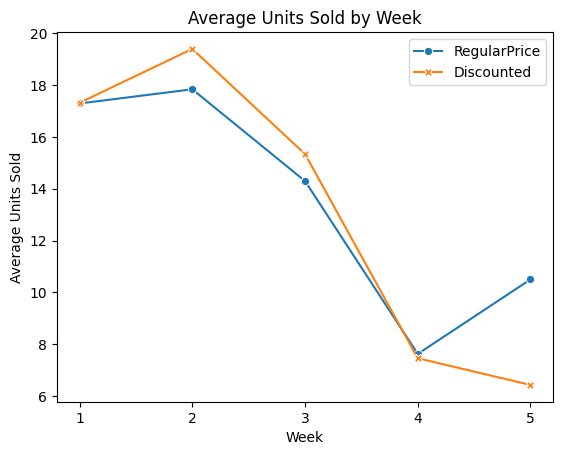

In [0]:
sns.lineplot(data=trend, x="week", y="mean_units", hue="group_label", style="group_label", markers=True, dashes=False)
plt.xlabel("Week")
plt.ylabel("Average Units Sold")
plt.title("Average Units Sold by Week")
plt.xticks(week_list)
plt.legend(title="")
plt.show()